# AG-HYPOPT · Trial 07

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Six trials recorded; best is trial 05 (0.0196). Trial 01 0.0981, trial 02 0.0246, trial 03 0.0477, trial 04 0.0262, trial 05 0.0196, trial 06 0.0329. Trial 06 (the first TPE pick, sigma_ref 7.64) sharpened the picture: sigma_ref is a monotone mu lever - mu rel RMSE rises 15.3% (sr 6.28) -> 17.2% (6.62) -> 17.5% (6.84) -> 21.2% (7.64) -> 27.7% (9.37) - so smaller sigma_ref is better, and lr_mu has a clear peak near 27 (lr_mu 10 -> 0.098, 23 -> 0.048, 25 -> 0.025, 27 -> 0.020, 29 -> 0.026). gamma is weakly sensitive to lr_gamma and gamma_anneal; residual error stays at low signal (Trans05). We are now in the TPE phase (7th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_07'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (6/5 trials)
ID |     ei | params
 1 | 3.8914 | {"gamma_anneal": 0.44826313625805264, "lr_gamma": 0.4287760772957329, "lr_mu": 26.838836134906547, "sigma_ref": 21.424568367655326}
 2 | 3.7458 | {"gamma_anneal": 0.12507599073136316, "lr_gamma": 0.42274048968061867, "lr_mu": 16.126907647066165, "sigma_ref": 6.468892889148847}
 3 | 3.5674 | {"gamma_anneal": 0.14374665255742264, "lr_gamma": 0.40379356837066727, "lr_mu": 9.005300846446113, "sigma_ref": 6.356309880132004}
 4 | 3.9592 | {"gamma_anneal": 0.3861666152035277, "lr_gamma": 0.4115770397368759, "lr_mu": 27.08009402797008, "sigma_ref": 6.157444464863774}
 5 | 0.1507 | {"gamma_anneal": 0.5190240906613794, "lr_gamma": 0.49562904848176537, "lr_mu": 25.751193245043638, "sigma_ref": 10.351986091275709}
 6 | 3.8647 | {"gamma_anneal": 0.2035212352512811, "lr_gamma": 0.43964929391287444, "lr_mu": 24.039872888716744, "sigma_ref": 6.315977436575738}
 7 | 3.7712 | {"gamma_anneal": 0.42554287420356174, "lr_gamma": 0.4047291135096

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 05 (0.0196: lr_mu 26.99, sigma_ref 6.28, lr_gamma 0.42, gamma_anneal 0.42). The trials pin down two strong levers: lr_mu peaked near 27, and sigma_ref monotone (smaller is better, the optimum at or below trial 05's 6.28). Reading the TPE batch by ei (higher = more promising, as in the 5-trial batch), the top draw is candidate 4 (ei 3.96): lr_mu 27.08, sigma_ref 6.16, lr_gamma 0.412, gamma_anneal 0.386. That is almost exactly the winning region of trial 05 with sigma_ref a little lower - consistent with everything the trials have shown - so it is both the model's top proposal and the empirically most sensible step, and it tests whether dropping sigma_ref just below 6.28 squeezes out a further mu gain (the high-ei candidates #1/#7/#8 instead sit at sigma_ref 13.8-21.4, already shown harmful, and #2/#3 drop lr_mu to 16/9). The lone low-ei outlier #5 (ei 0.15) also has the bad sigma_ref 10.35. I choose candidate 4.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.3861666152035277, 'lr_gamma': 0.4115770397368759, 'lr_mu': 27.08009402797008, 'sigma_ref': 6.157444464863774}
Running  1nW Trans05 ... 

μ 9.39 -> 6.89 | γ 8.5 -> 6.94 | NLL 1.31


Running  1nW Trans20 ... 

μ 17.32 -> 15.81 | γ 8.5 -> 7.86 | NLL 2.81


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 99.87 | γ 14.1 -> 13.88 | NLL 3.29


Running 3nW Trans100 ... 

μ 175.71 -> 162.92 | γ 14.1 -> 13.90 | NLL 3.06



Total: 7.2 min


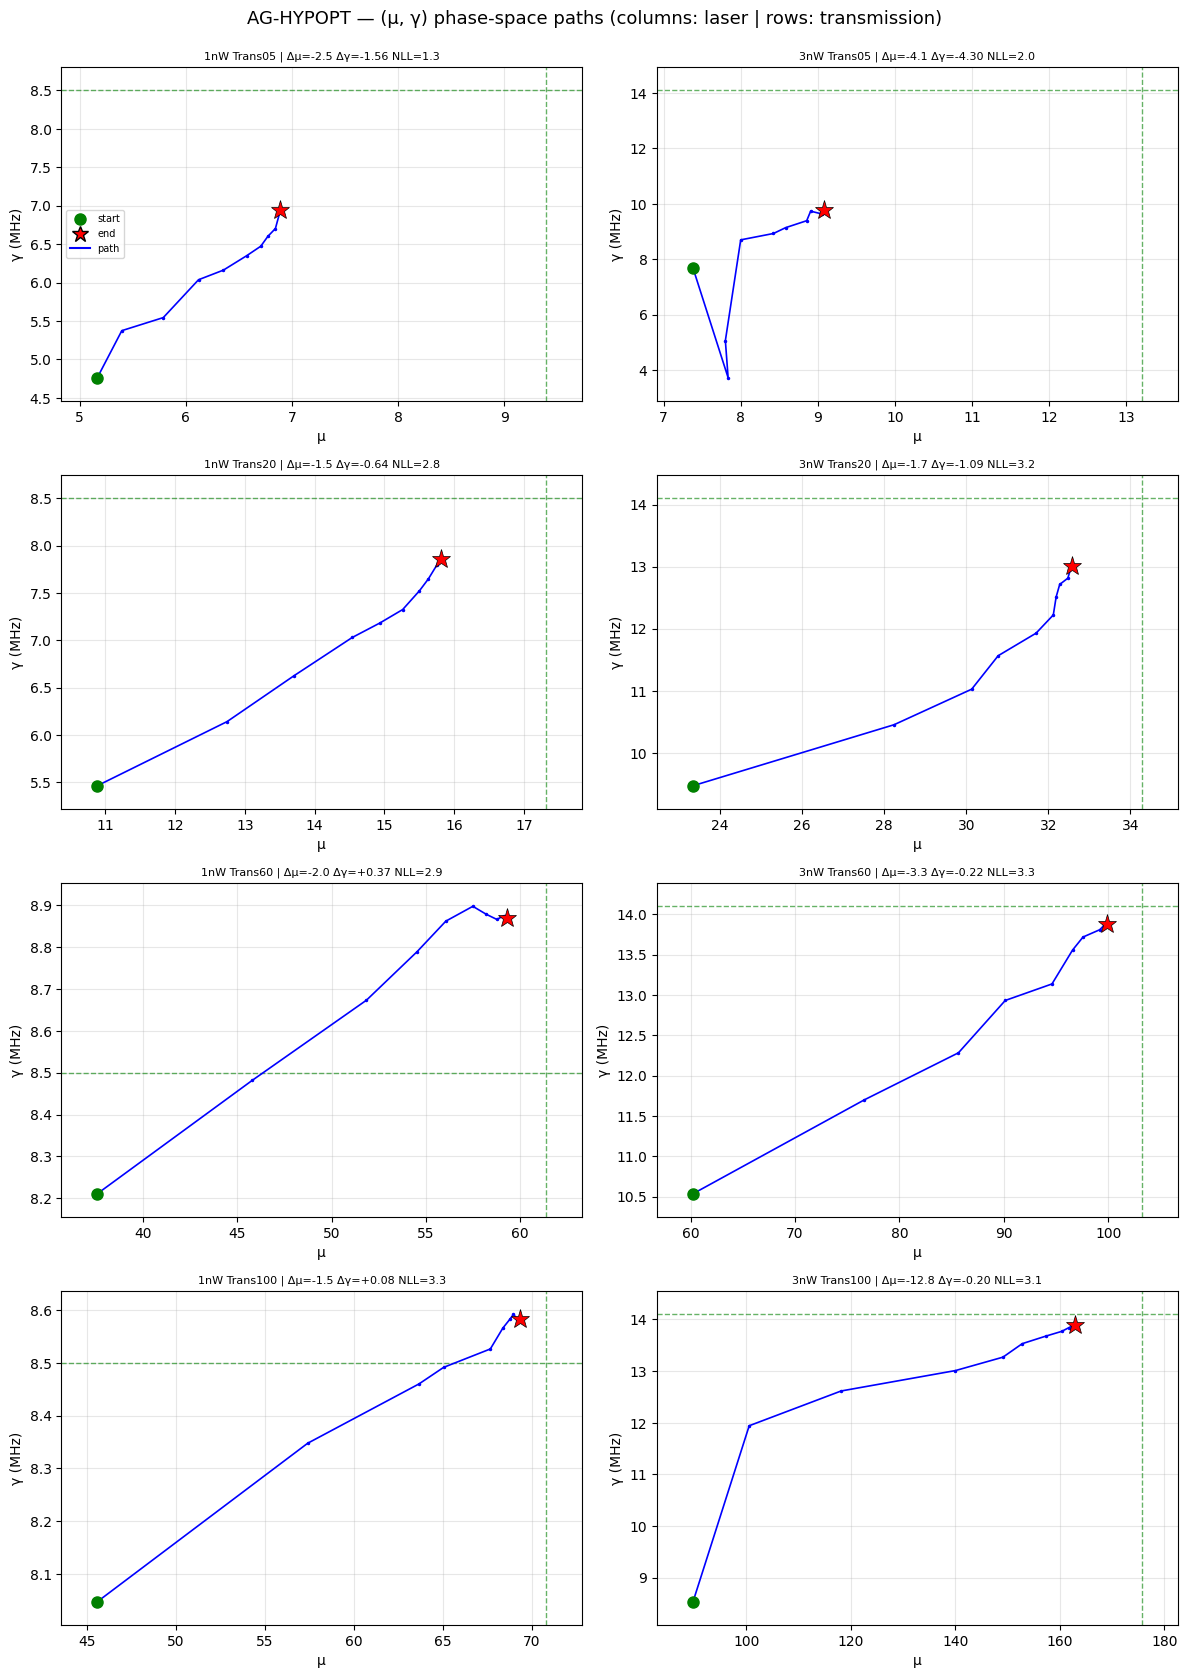

trial finished in 7.2 min
objective = 0.0205 ± 0.0086
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.89   -26.6 |     8.50    6.94   -18.3
1nW Trans20    17.32   15.81    -8.7 |     8.50    7.86    -7.5
1nW Trans60    61.37   59.33    -3.3 |     8.50    8.87    +4.3
1nW Trans100   70.82   69.33    -2.1 |     8.50    8.58    +1.0
3nW Trans05    13.20    9.08   -31.3 |    14.10    9.80   -30.5
3nW Trans20    34.28   32.57    -5.0 |    14.10   13.01    -7.7
3nW Trans60   103.20   99.87    -3.2 |    14.10   13.88    -1.5
3nW Trans100  175.71  162.92    -7.3 |    14.10   13.90    -1.4

μ: RMSE 5.116 (rel 15.3%, bias -3.687) | γ: RMSE 1.687 (rel 13.3%, bias -0.945)


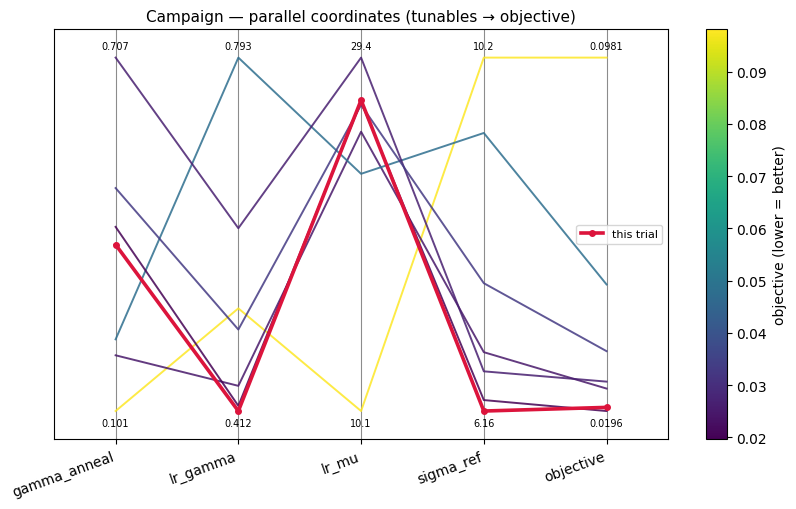

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 07 (sigma_ref 6.16, lr_mu 27.08, lr_gamma 0.41, gamma_anneal 0.39) was the TPE top draw (ei 3.96) and the tightest neighbourhood of trial 05. It ran 7.2 min and scored 0.0205 +/- 0.0086, statistically indistinguishable from trial 05 (0.0196), which stays best. mu rel RMSE is 15.3%, identical to trial 05's 15.3%, so lowering sigma_ref from 6.28 to 6.16 did NOT improve mu: the mu optimum is saturated at sigma_ref ~6.3 and lr_mu ~27. gamma slipped slightly (12.6% -> 13.3%), again weakest at 3nW Trans05 (-30.5%). The two best trials now bracket the optimum tightly (lr_mu ~27, sigma_ref ~6.2-6.3, lr_gamma ~0.41-0.42, gamma_anneal ~0.39-0.42) and land at the same mu floor of 15.3%, which suggests the hyperparameter search has converged on mu and that the remaining error is dominated by the low-signal regime rather than by these four tunables.

**Summary:** Trial 07 (sigma_ref 6.16, lr_mu 27.08, lr_gamma 0.41, gamma_anneal 0.39), the TPE top draw, scored 0.0205 +/- 0.0086, tied with trial 05: mu stayed at 15.3% (sigma_ref below 6.3 adds nothing) and gamma was slightly worse at 13.3%.
**Key insight:** mu has saturated around sigma_ref ~6.3 and lr_mu ~27 (lowering sigma_ref to 6.16 gave no mu gain), so further gains must come from the residual low-signal (Trans05) behaviour rather than from these tunables.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 07 (sigma_ref 6.16, lr_mu 27.08, lr_gamma 0.41, gamma_anneal 0.39), the TPE top draw, scored 0.0205 +/- 0.0086, tied with trial 05: mu stayed at 15.3% (sigma_ref below 6.3 adds nothing) and gamma was slightly worse at 13.3%.'
KEY_INSIGHT = 'mu has saturated around sigma_ref ~6.3 and lr_mu ~27 (lowering sigma_ref to 6.16 gave no mu gain), so further gains must come from the residual low-signal (Trans05) behaviour rather than from these tunables.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_07 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_08.ipynb. Open it and follow its cells from the top.
